# Final Project: Differentiated Thyroid Cancer Recurrence Dataset

## 1. Data Selection

**Dataset Name:** Differentiated Thyroid Cancer Recurrence

**Source URL:** https://archive.ics.uci.edu/dataset/915/differentiated+thyroid+cancer+recurrence

**Why This Dataset Was Selected:**
I selected this dataset because it aligns with my interest in pursuing a computational biology or healthcare data-focused role. Predicting whether a patient's thyroid cancer will recur based on their clinical profile felt like a realistic and significant classification problem. I also wanted experience working with a mix of categorical and numeric clinical variables, since cleaning this type of data is something I will likely encounter in future research or professional work.

**Verification of Project Criteria:**
- Hosted on UCI ML Repository
- Binary target variable (`Recurred`: Yes/No)
- 383 observations (exceeds minimum of 300)
- 16 predictor variables (exceeds minimum of 10)

In [1]:
import pandas as pd

df = pd.read_csv('Thyroid_Diff.csv')
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## 2. Dataset Exploration

### Dataset Structure
The dataset contains 383 patient records, each with 16 predictor variables plus the target variable (`Recurred`). Each row represents a unique patient, and columns include a mix of categorical (e.g., Gender, Smoking, Pathology) and numeric (e.g., Age) variables.

In [2]:
df.info()
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

### Target Variable
`Recurred` — a binary variable indicating whether the patient's thyroid cancer recurred (Yes/No).

### Predictor Variables
The dataset includes demographic variables (Age, Gender), lifestyle/history variables (Smoking, History of Smoking, History of Radiotherapy), and clinical/diagnostic variables (Thyroid Function, Physical Examination, Adenopathy, Pathology, Focality, Risk classification, T/N/M staging, Overall Stage, and Treatment Response).

In [3]:
df.describe(include='all')

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,NaN,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,NaN,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,NaN,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275
mean,40.866841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.134494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df['Recurred'].value_counts(normalize=True)

,proportion
Recurred,
No,0.718016
Yes,0.281984


### Exploratory Visualizations

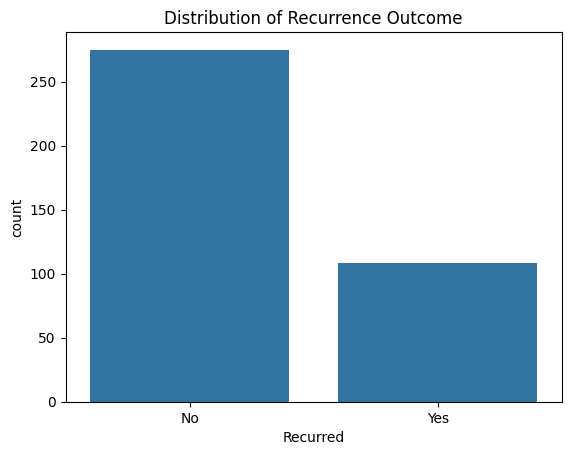

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Recurred', data=df)
plt.title('Distribution of Recurrence Outcome')
plt.show()

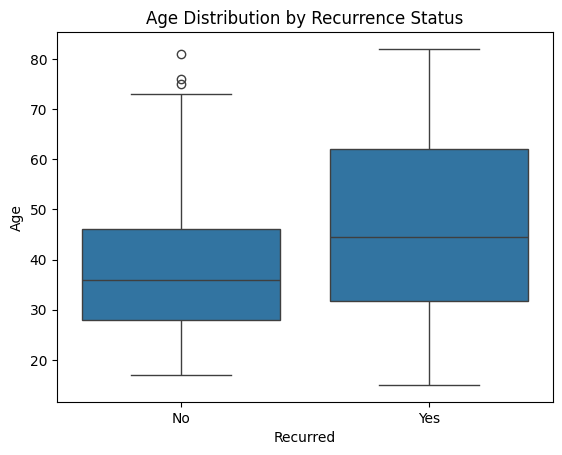

In [6]:
sns.boxplot(x='Recurred', y='Age', data=df)
plt.title('Age Distribution by Recurrence Status')
plt.show()

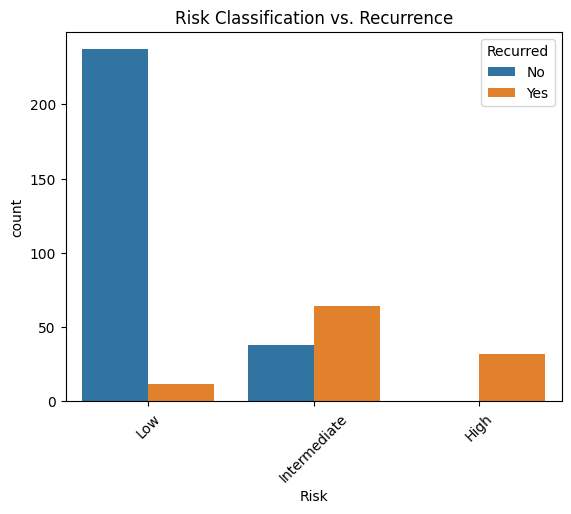

In [7]:
sns.countplot(x='Risk', hue='Recurred', data=df)
plt.title('Risk Classification vs. Recurrence')
plt.xticks(rotation=45)
plt.show()

## 3. Data Quality Assessment

### Missing Values / Improper Coding

In [8]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


In [9]:
for col in df.columns:
    print(col, ":", df[col].unique())

Age : [27 34 30 62 52 41 46 51 40 75 59 49 50 76 42 44 43 36 70 60 33 26 37 55
 31 45 20 38 29 25 21 23 24 35 54 22 69 28 17 73 18 39 57 66 32 47 56 63
 19 67 72 61 68 48 81 53 58 80 79 65 15 82 71 64 78]
Gender : ['F' 'M']
Smoking : ['No' 'Yes']
Hx Smoking : ['No' 'Yes']
Hx Radiothreapy : ['No' 'Yes']
Thyroid Function : ['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']
Physical Examination : ['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']
Adenopathy : ['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']
Pathology : ['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']
Focality : ['Uni-Focal' 'Multi-Focal']
Risk : ['Low' 'Intermediate' 'High']
T : ['T1a' 'T1b' 'T2' 'T3a' 'T3b' 'T4a' 'T4b']
N : ['N0' 'N1b' 'N1a']
M : ['M0' 'M1']
Stage : ['I' 'II' 'IVB' 'III' 'IVA']
Response : ['Indeterminate' 'Excellent' 'Structural Incomplete'
 'Biochemica

I'll check each categorical column for inconsistent labeling (typos, inconsistent capitalization) and confirm whether any values are coded as placeholders ("Unknown" or blank spaces) rather than true missing values.

### Anticipated Preprocessing Steps
- Encoding categorical variables since most predictors are categorical rather than numeric
- Scaling the numeric Age variable if using distance-based models
- Checking for and addressing class imbalance in the `Recurred` target, since recurrence is likely the minority class
- Reviewing staging variables (T, N, M, Overall Stage) for potential redundancy or multicollinearity, since they may overlap

### Potential Challenges
- Class imbalance, since most patients likely did not experience recurrence
- High number of categorical variables with multiple levels, which could increase dimensionality significantly after one-hot encoding
- Relatively small sample size (383) relative to the number of encoded features, which increases risk of overfitting
- Some clinical variables (e.g., staging) may be highly correlated with each other, requiring careful feature selection

## 4. Project Planning

**Proposed Prediction Problem:**
Using demographic and clinical variables at the time of diagnosis to predict whether a patient's differentiated thyroid cancer will recur.

**Target Variable:**
`Recurred` (binary: Yes = 1, No = 0)

**Candidate Evaluation Metric:**
Since recurrence cases are likely a minority class compared to non-recurrence cases, I plan to prioritize **F1-score** and **AUC-ROC** over raw accuracy, as these metrics better reflect performance when classes are imbalanced. I will use cross-validation to ensure results are consistent across different subsets of the data.